In [1]:
# Cell 1: imports + local paths + device
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# Local paths
model_dir = os.path.join('.', 'outputs', 'models')
save_dir = os.path.join('.', 'outputs', 'reinforce3')
os.makedirs(save_dir, exist_ok=True)

# Experiment config
latent_dims_to_compare = [16, 32, 64, 80]
runs_per_dim = 5

# Default latent dim; overwritten per checkpoint
latent_dim = 32

cpu


In [2]:
# Cell 2: VAE + classifier definitions
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=80):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


clf_path = os.path.join(model_dir, "classifier.pt")
if not os.path.exists(clf_path):
    raise FileNotFoundError(f"Missing checkpoint: {clf_path}")

clf = Classifier().to(device)
clf.load_state_dict(torch.load(clf_path, map_location=device))
clf.eval()

print("classifier loaded")

FileNotFoundError: Missing checkpoint: .\outputs\models\classifier.pt

In [ ]:
# Cell 3: data + helper functions
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

def get_digit(digit):
    for x, y in train_dataset:
        if y == digit:
            return x.unsqueeze(0)

x2 = get_digit(2).to(device)
x6 = get_digit(6).to(device)

def interpolate(z2, z6, alpha):
    return (1 - alpha) * z2 + alpha * z6

def plot_opt_PCA(dataset):
    X = dataset.data.numpy()
    y = dataset.targets.numpy()
    # Keep only digits 2 and 6
    mask_26 = (y == 2) | (y == 6)
    X_26 = X[mask_26]
    y_26 = y[mask_26]

    # Flatten images for PCA: (n_samples, 28, 28) -> (n_samples, 784)
    X_26_flat = X_26.reshape(X_26.shape[0], -1).astype(np.float32)

    # Standard PCA on centered data
    pca = PCA()
    pca.fit(X_26_flat)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    # Dimensionality estimates by retained variance
    k90 = np.searchsorted(cumulative, 0.90) + 1
    k95 = np.searchsorted(cumulative, 0.95) + 1
    k99 = np.searchsorted(cumulative, 0.99) + 1

    print(f"Samples (2s and 6s): {X_26_flat.shape[0]}")
    print(f"Original dimension: {X_26_flat.shape[1]}")
    print(f"Components for 90% variance: {k90}")
    print(f"Components for 95% variance: {k95}")
    print(f"Components for 99% variance: {k99}")

    print("\nExplained variance ratio for each dimension:")
    for dim, ratio in enumerate(explained, start=1):
        print(f"PC{dim}: {ratio:.6f}")

    # Plot explained variance ratio for each principal component
    dims = np.arange(1, len(explained) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(dims, explained, linewidth=1.5)
    plt.xlim(1, 200)
    plt.xlabel('Principal Component Dimension')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Explained Variance Ratio by PCA Dimension (Digits 2 and 6)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Visualize cumulative explained variance
    plt.figure(figsize=(8, 4))
    plt.plot(dims, cumulative, linewidth=2)
    plt.axhline(0.90, linestyle='--')
    plt.axhline(0.95, linestyle='--')
    plt.axhline(0.99, linestyle='--')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance (Digits 2 and 6)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def total_variation(x):
    if x.dim() == 3:
        x = x.unsqueeze(0)
    tv_h = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean(dim=(1, 2, 3))
    tv_w = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean(dim=(1, 2, 3))
    return tv_h + tv_w

def reward_fn(x, beta=1.0, lambda_tv=0.08, lambda_off=0.40):
    single = (x.dim() == 3)
    if single:
        x_in = x.unsqueeze(0)
    else:
        x_in = x

    with torch.no_grad():
        logits = clf(x_in)
        probs = F.softmax(logits, dim=1)

    p2 = probs[:, 2]
    p6 = probs[:, 6]

    main = (p2 + p6) - beta * (p2 - p6) ** 2
    off = 1.0 - p2 - p6
    tv = total_variation(x_in)

    reward = main - lambda_tv * tv - lambda_off * off

    info = {
        "main": main.detach(),
        "off": off.detach(),
        "tv": tv.detach(),
        "p2": p2.detach(),
        "p6": p6.detach(),
        "pred": probs.argmax(dim=1).detach()
    }

    if single:
        reward = reward[0]
        info = {k: v[0] for k, v in info.items()}

    return reward, info

def compute_returns(rewards, gamma=0.95):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.stack(returns)

In [ ]:
# Cell 4: policy + rollout
class Policy(nn.Module):
    def __init__(self, dim, hidden=128, action_scale=0.15):
        super().__init__()
        self.action_scale = action_scale
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )
        self.log_std = nn.Parameter(torch.zeros(dim))

    def forward(self, z):
        mu = self.action_scale * torch.tanh(self.net(z))
        std = torch.exp(self.log_std).unsqueeze(0).expand_as(mu)
        return mu, std

    def act(self, z, sample=True):
        mu, std = self.forward(z)
        dist = torch.distributions.Normal(mu, std)

        if sample:
            a = dist.rsample()
            logp = dist.log_prob(a).sum(dim=-1)
        else:
            a = mu
            logp = torch.zeros(z.shape[0], device=z.device)

        return a, logp, mu, std


policy = Policy(dim=latent_dim, hidden=128, action_scale=0.15).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-4)

def rollout_episode(policy, z0, T, step_size, sample=True):
    z = z0.clone()
    logps = []
    rewards = []

    for t in range(T):
        action, logp, mu, std = policy.act(z, sample=sample)
        z = z + step_size * action

        with torch.no_grad():
            x = decoder(z)   # [1, 1, 28, 28]

        r, _ = reward_fn(x)

        logps.append(logp.squeeze())
        rewards.append(r.squeeze())

    logps = torch.stack(logps)      # [T]
    rewards = torch.stack(rewards)  # [T]

    return z, logps, rewards

In [ ]:
# Cell 5: train across dimensions and runs
num_epochs = 200
batch_size = 20
T = 10
step_size = 0.4
gamma = 0.95
print_every = 10

experiment_rows = []
all_run_reward_curves = {}
all_run_loss_curves = {}
final_images_by_dim = {d: [] for d in latent_dims_to_compare}
all_series_records = []

plot_opt_PCA(train_dataset)

for dim in latent_dims_to_compare:
    vae_path = os.path.join(model_dir, f"vae_{dim}.pt")
    if not os.path.exists(vae_path):
        raise FileNotFoundError(f"Missing checkpoint: {vae_path}")

    vae_state = torch.load(vae_path, map_location=device)
    inferred_dim = vae_state["fc_mu.weight"].shape[0]
    if inferred_dim != dim:
        raise ValueError(f"Checkpoint dim mismatch for {vae_path}: expected {dim}, got {inferred_dim}")

    vae = VAE(latent_dim=dim).to(device)
    vae.load_state_dict(vae_state)
    vae.eval()

    class EncoderAdapter(nn.Module):
        def __init__(self, vae_model):
            super().__init__()
            self.vae = vae_model

        def forward(self, x):
            mu, _ = self.vae.encode(x)
            return mu

    class DecoderAdapter(nn.Module):
        def __init__(self, vae_model):
            super().__init__()
            self.vae = vae_model

        def forward(self, z):
            return self.vae.decode(z)

    encoder = EncoderAdapter(vae).to(device)
    decoder = DecoderAdapter(vae).to(device)
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        z2 = encoder(x2)
        z6 = encoder(x6)

    all_run_reward_curves[dim] = []
    all_run_loss_curves[dim] = []

    for run_idx in range(1, runs_per_dim + 1):
        run_dir = os.path.join(save_dir, f"dim_{dim}", f"run_{run_idx}")
        img_save_dir = os.path.join(run_dir, "epoch_images")
        os.makedirs(img_save_dir, exist_ok=True)

        print(f"\n=== dim={dim} | run={run_idx}/{runs_per_dim} ===")

        policy = Policy(dim=dim, hidden=128, action_scale=0.15).to(device)
        optimizer = optim.Adam(policy.parameters(), lr=1e-4)
        policy.train()

        reward_history = []
        loss_history = []
        last_z = None
        info_dbg = None

        for epoch in range(num_epochs):
            batch_loss = 0.0
            batch_reward = 0.0
            optimizer.zero_grad()

            for _ in range(batch_size):
                alpha0 = torch.tensor([0.575], device=device)
                z0 = interpolate(z2, z6, alpha0)

                z_final, logps, rewards = rollout_episode(
                    policy=policy,
                    z0=z0,
                    T=T,
                    step_size=step_size,
                    sample=True
                )

                returns = compute_returns(rewards, gamma=gamma)
                returns = (returns - returns.mean()) / (returns.std() + 1e-8)

                loss = -(logps * returns.detach()).mean()
                loss.backward()

                batch_loss += loss.item()
                batch_reward += rewards.mean().item()
                last_z = z_final.detach()

            optimizer.step()

            batch_loss /= batch_size
            batch_reward /= batch_size

            loss_history.append(batch_loss)
            reward_history.append(batch_reward)

            with torch.no_grad():
                last_x = decoder(last_z)
                _, info_dbg = reward_fn(last_x)
                last_img = last_x.squeeze().cpu()

            plt.figure(figsize=(3, 3))
            plt.imshow(last_img, cmap="gray")
            plt.title(f"dim={dim} run={run_idx} epoch={epoch}\nreward={batch_reward:.4f}")
            plt.axis("off")
            plt.tight_layout()
            plt.savefig(os.path.join(img_save_dir, f"epoch_{epoch:03d}.png"), dpi=150, bbox_inches="tight")
            plt.close()

            if epoch % print_every == 0:
                print(
                    f"dim={dim} run={run_idx} epoch={epoch}, "
                    f"reward={batch_reward:.6f}, "
                    f"loss={batch_loss:.6f}, "
                    f"p2={info_dbg['p2'].item():.4f}, "
                    f"p6={info_dbg['p6'].item():.4f}, "
                    f"off={info_dbg['off'].item():.4f}, "
                    f"tv={info_dbg['tv'].item():.4f}, "
                    f"pred={info_dbg['pred'].item()}"
                )

        # Evaluation rollout and final output capture
        policy.eval()
        alpha_test = torch.tensor([0.575], device=device)
        z = interpolate(z2, z6, alpha_test)
        direction = z6 - z2
        direction_norm_sq = (direction * direction).sum(dim=-1, keepdim=True)

        test_rewards = []
        test_alphas = []
        test_imgs = []

        with torch.no_grad():
            for _ in range(11):
                x = decoder(z)
                r, _ = reward_fn(x)

                alpha_proj = ((z - z2) * direction).sum(dim=-1, keepdim=True) / (direction_norm_sq + 1e-8)

                test_rewards.append(r.item())
                test_alphas.append(alpha_proj.item())
                test_imgs.append(x.squeeze().cpu())

                a, _, _, _ = policy.act(z, sample=True)
                z = z + step_size * a

        final_img = test_imgs[-1]
        final_reward = float(test_rewards[-1])
        max_reward = float(max(test_rewards))
        final_alpha = float(test_alphas[-1])

        final_images_by_dim[dim].append(final_img)
        all_run_reward_curves[dim].append(reward_history)
        all_run_loss_curves[dim].append(loss_history)

        # Save run-level series artifacts
        series_records = []
        for i, img in enumerate(test_imgs):
            plt.figure(figsize=(2.5, 2.5))
            plt.imshow(img, cmap="gray")
            plt.title(f"step={i}\nr={test_rewards[i]:.3f}\na={test_alphas[i]:.2f}")
            plt.axis("off")
            plt.tight_layout()
            step_path = os.path.join(run_dir, f"step_{i:02d}.png")
            plt.savefig(step_path, dpi=150, bbox_inches="tight")
            plt.close()

            series_records.append({
                "dim": dim,
                "run": run_idx,
                "step": i,
                "reward": test_rewards[i],
                "alpha_proj": test_alphas[i],
                "image_path": step_path,
            })

        df_series = pd.DataFrame(series_records)
        df_series.to_csv(os.path.join(run_dir, "series_metrics.csv"), index=False)
        all_series_records.extend(series_records)

        # Save run-level summary row
        experiment_rows.append({
            "latent_dim": dim,
            "run": run_idx,
            "final_train_reward": float(reward_history[-1]),
            "max_train_reward": float(max(reward_history)),
            "final_train_loss": float(loss_history[-1]),
            "final_eval_reward": final_reward,
            "max_eval_reward": max_reward,
            "final_alpha_proj": final_alpha,
            "run_dir": run_dir,
        })

print("\nCompleted all dimension/run experiments.")


=== dim=16 | run=1/5 ===
dim=16 run=1 epoch=0, reward=0.354821, loss=0.000813, p2=0.9999, p6=0.0001, off=0.0000, tv=0.1253, pred=2
dim=16 run=1 epoch=10, reward=0.279437, loss=0.127902, p2=0.0222, p6=0.9778, off=0.0000, tv=0.1219, pred=6
dim=16 run=1 epoch=20, reward=0.285562, loss=0.030276, p2=0.0220, p6=0.9780, off=0.0000, tv=0.1331, pred=6
dim=16 run=1 epoch=30, reward=0.323104, loss=0.340357, p2=0.0008, p6=0.9992, off=0.0000, tv=0.1271, pred=6
dim=16 run=1 epoch=40, reward=0.265674, loss=-0.295397, p2=0.9932, p6=0.0067, off=0.0001, tv=0.0896, pred=2
dim=16 run=1 epoch=50, reward=0.256716, loss=-0.040663, p2=0.0315, p6=0.9677, off=0.0008, tv=0.0903, pred=6
dim=16 run=1 epoch=60, reward=0.234667, loss=-0.038106, p2=0.0283, p6=0.9717, off=0.0000, tv=0.1187, pred=6
dim=16 run=1 epoch=70, reward=0.246926, loss=0.033025, p2=0.9977, p6=0.0023, off=0.0000, tv=0.1387, pred=2
dim=16 run=1 epoch=80, reward=0.220623, loss=-0.021029, p2=0.9232, p6=0.0767, off=0.0001, tv=0.1177, pred=2
dim=16 r

    latent_dim  run  final_train_reward  max_train_reward  final_train_loss  \
0           16    1            0.334001          0.450961         -0.207288   
1           16    2            0.376485          0.460589         -0.123926   
2           16    3            0.285543          0.449607         -0.271854   
3           16    4            0.302102          0.431520         -0.049772   
4           16    5            0.303626          0.442923         -0.081390   
5           32    1            0.368388          0.496824          0.381113   
6           32    2            0.265311          0.474257         -0.015576   
7           32    3            0.324274          0.497471         -0.093104   
8           32    4            0.310968          0.458451          0.053984   
9           32    5            0.341264          0.460223         -0.016857   
10          64    1            0.311009          0.482992          0.104811   
11          64    2            0.383927          0.4

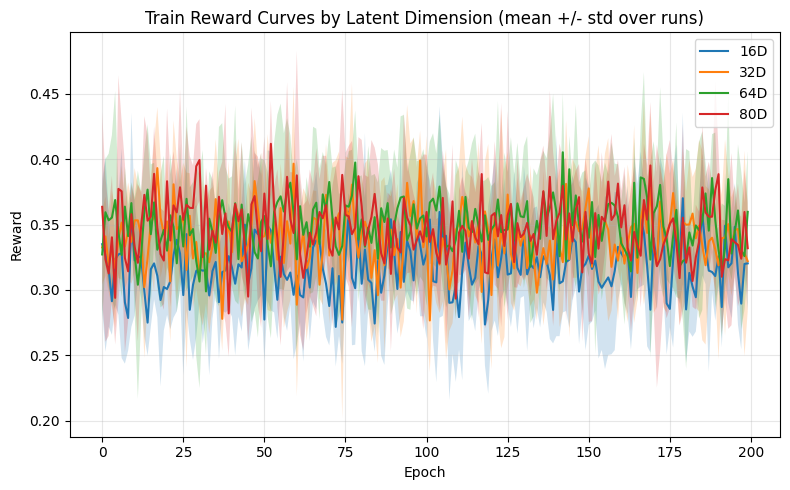

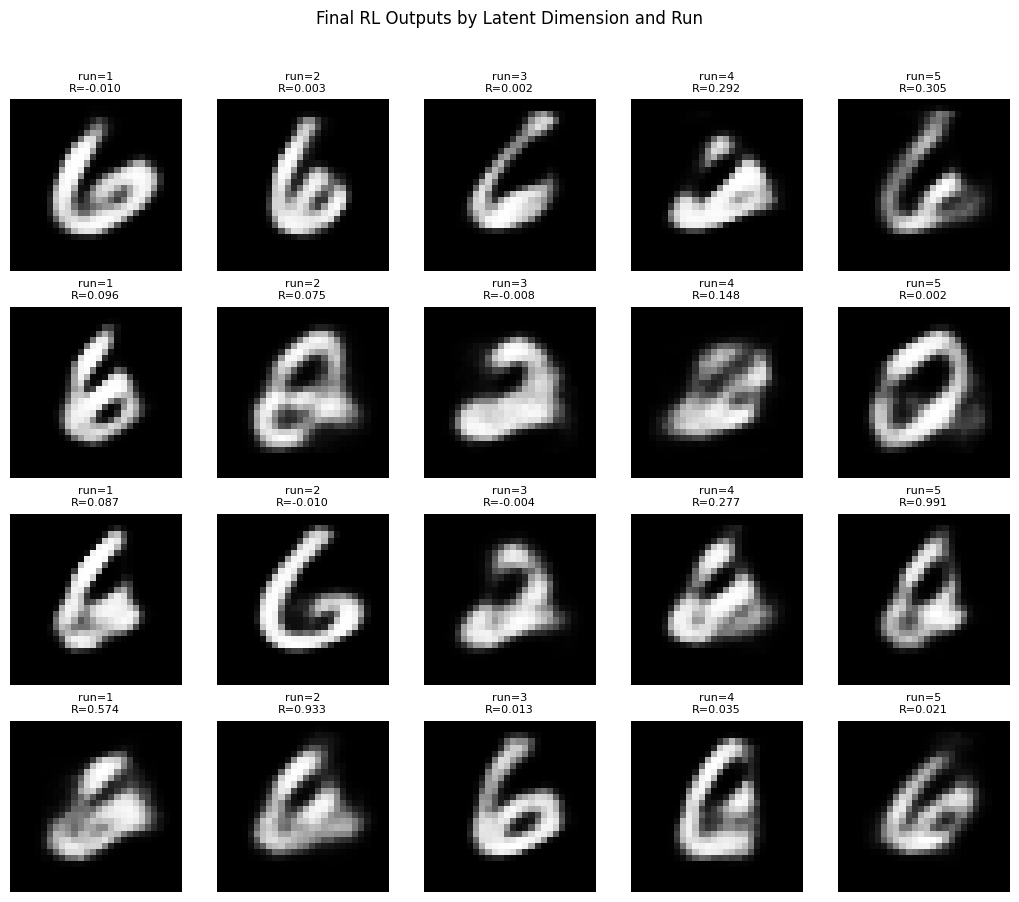

In [ ]:
# Cell 6: aggregate plots and final-output comparison
if len(experiment_rows) == 0:
    raise RuntimeError("No experiment results found. Run Cell 5 first.")

summary_df = pd.DataFrame(experiment_rows).sort_values(["latent_dim", "run"])
print(summary_df)

# Plot mean +/- std train reward curves per dimension
plt.figure(figsize=(8, 5))
for dim in latent_dims_to_compare:
    curves = torch.tensor(all_run_reward_curves[dim], dtype=torch.float32)  # [runs, epochs]
    mean_curve = curves.mean(dim=0).cpu().numpy()
    std_curve = curves.std(dim=0).cpu().numpy()
    x = range(len(mean_curve))
    plt.plot(x, mean_curve, label=f"{dim}D")
    plt.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)
plt.title("Train Reward Curves by Latent Dimension (mean +/- std over runs)")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Final output image grid: one row per dimension, one column per run
rows = len(latent_dims_to_compare)
cols = runs_per_dim
fig, axes = plt.subplots(rows, cols, figsize=(2.1 * cols, 2.2 * rows))
if rows == 1:
    axes = [axes]

for r, dim in enumerate(latent_dims_to_compare):
    for c in range(cols):
        ax = axes[r][c] if rows > 1 else axes[c]
        ax.imshow(final_images_by_dim[dim][c], cmap="gray")
        run_num = c + 1
        row = summary_df[(summary_df["latent_dim"] == dim) & (summary_df["run"] == run_num)].iloc[0]
        ax.set_title(f"run={run_num}\nR={row['final_eval_reward']:.3f}", fontsize=8)
        ax.axis("off")
    if rows > 1:
        axes[r][0].set_ylabel(f"{dim}D", fontsize=10)

plt.suptitle("Final RL Outputs by Latent Dimension and Run", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: save aggregate comparison outputs
if len(experiment_rows) == 0:
    raise RuntimeError("No experiment results found. Run Cell 5 first.")

summary_df = pd.DataFrame(experiment_rows).sort_values(["latent_dim", "run"])
summary_csv = os.path.join(save_dir, "comparison_summary.csv")
summary_df.to_csv(summary_csv, index=False)

series_df = pd.DataFrame(all_series_records)
series_csv = os.path.join(save_dir, "comparison_series_metrics.csv")
series_df.to_csv(series_csv, index=False)

agg_df = summary_df.groupby("latent_dim").agg(
    mean_final_eval_reward=("final_eval_reward", "mean"),
    std_final_eval_reward=("final_eval_reward", "std"),
    mean_max_eval_reward=("max_eval_reward", "mean"),
    std_max_eval_reward=("max_eval_reward", "std"),
).reset_index().sort_values("latent_dim")
agg_csv = os.path.join(save_dir, "comparison_by_dim.csv")
agg_df.to_csv(agg_csv, index=False)

print("Saved aggregate comparison artifacts:")
print(summary_csv)
print(series_csv)
print(agg_csv)
print("\nBy-dimension summary:")
print(agg_df)

Saved aggregate comparison artifacts:
.\outputs\reinforce3\comparison_summary.csv
.\outputs\reinforce3\comparison_series_metrics.csv
.\outputs\reinforce3\comparison_by_dim.csv

By-dimension summary:
   latent_dim  mean_final_eval_reward  std_final_eval_reward  \
0          16                0.118229               0.164382   
1          32                0.062757               0.065689   
2          64                0.268232               0.420455   
3          80                0.315201               0.419736   

   mean_max_eval_reward  std_max_eval_reward  
0              0.974591             0.025650  
1              0.980527             0.008558  
2              0.917558             0.059847  
3              0.988181             0.000000  


Best runs by dimension based on final eval reward:
    latent_dim  run  final_eval_reward
4           16    5           0.304500
8           32    4           0.148238
14          64    5           0.991318
16          80    2           0.932976


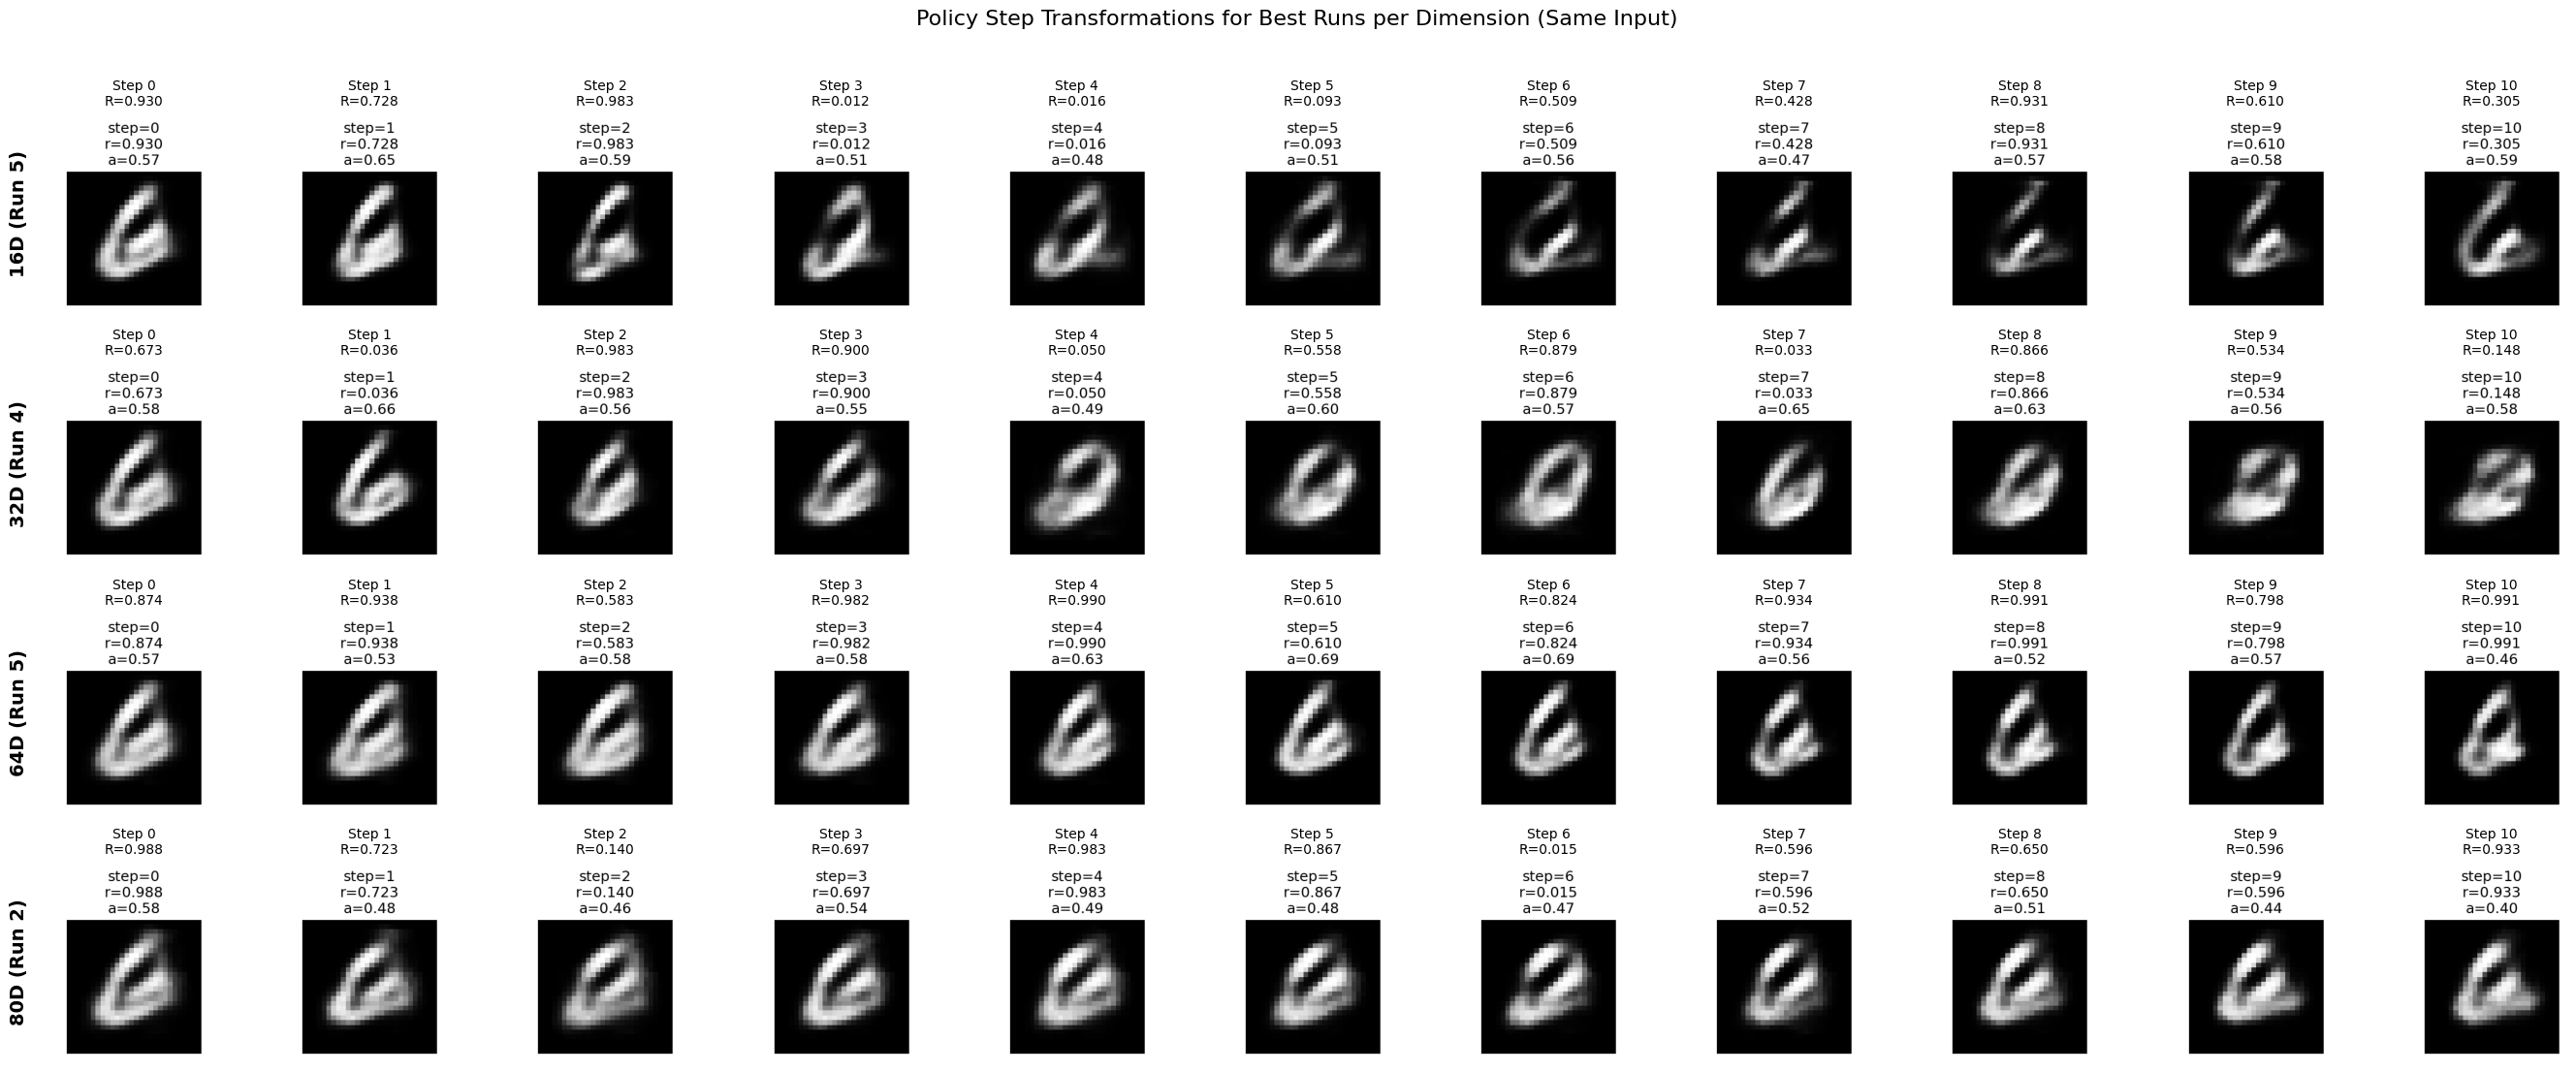

In [ ]:
import matplotlib.image as mpimg

# Find the best run for each dimension
best_runs = summary_df.loc[summary_df.groupby("latent_dim")["final_eval_reward"].idxmax()]

print("Best runs by dimension based on final eval reward:")
print(best_runs[["latent_dim", "run", "final_eval_reward"]])

# Get the series records
num_steps = 11  # step_00 to step_10

fig, axes = plt.subplots(len(latent_dims_to_compare), num_steps, figsize=(2.5 * num_steps, 2.7 * len(latent_dims_to_compare)))

for r, dim in enumerate(latent_dims_to_compare):
    best_run = best_runs[best_runs["latent_dim"] == dim]["run"].iloc[0]
    
    # Filter series for this dim and best run
    dim_run_series = series_df[(series_df["dim"] == dim) & (series_df["run"] == best_run)].sort_values("step")
    
    for c, step in enumerate(range(num_steps)):
        ax = axes[r, c]
        if c < len(dim_run_series):
            step_row = dim_run_series.iloc[c]
            img_path = step_row["image_path"]
            reward = step_row["reward"]
            
            # Read image from disk
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                ax.imshow(img, cmap="gray")
                ax.set_title(f"Step {step}\nR={reward:.3f}", fontsize=10)
            else:
                ax.set_title(f"Missing Step {step}")
        else:
            ax.set_title(f"No Step {step}")
            
        ax.axis("off")
        
        # Add Y label just for the first column
        if c == 0:
            ax.set_ylabel(f"{dim}D\n(Run {best_run})", fontsize=12)
            # Make ylabel visible even with axis off by using annotate or text
            ax.text(-0.2, 0.5, f"{dim}D (Run {best_run})", 
                    fontsize=14, fontweight='bold', va='center', ha='right', 
                    rotation='vertical', transform=ax.transAxes)

plt.suptitle("Policy Step Transformations for Best Runs per Dimension (Same Input)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import os
from typing import Callable, Optional, Sequence, Union
from sklearn.neighbors import NearestNeighbors

FeatureFn = Callable[[torch.Tensor], np.ndarray]

try:
    import gudhi
    from persim import wasserstein as _wasserstein
    _TOPO_OK = True
except ImportError:
    _TOPO_OK = False

def _h1_diagram(img: np.ndarray) -> np.ndarray:
    """H1 persistence diagram (finite pairs only) of a 28x28 image via a
    cubical sublevel-set filtration.  Images are inverted so bright
    strokes form low-value basins that enclose H1 loops."""
    if not _TOPO_OK:
        raise ImportError("gudhi / persim required for H1 persistence")
    arr = 1.0 - np.asarray(img, dtype=np.float64).reshape(28, 28)
    cc = gudhi.CubicalComplex(
        dimensions=[28, 28],
        top_dimensional_cells=arr.flatten().tolist(),
    )
    cc.compute_persistence()
    dgm = cc.persistence_intervals_in_dimension(1)
    if len(dgm) == 0:
        return np.empty((0, 2), dtype=np.float64)
    finite = dgm[np.isfinite(dgm[:, 1])]
    return finite if len(finite) else np.empty((0, 2), dtype=np.float64)

def _safe_wasserstein(d1: np.ndarray, d2: np.ndarray) -> float:
    """Wasserstein-1 between two H1 diagrams, tolerant of empty diagrams
    (persim expects at least one point, so we inject a diagonal point)."""
    a = d1 if len(d1) else np.array([[0.0, 0.0]])
    b = d2 if len(d2) else np.array([[0.0, 0.0]])
    r = _wasserstein(a, b, matching=False)
    return float(r[0]) if isinstance(r, tuple) else float(r)

def h1_novelty(
    diagrams: Sequence[np.ndarray],
    reference: Sequence[np.ndarray],
) -> np.ndarray:
    """For each query diagram, minimum Wasserstein-1 distance to any
    reference diagram, squashed to [0, 1) as d / (1 + d).  High = this
    image's topology is unlike anything in the real data."""
    out = np.zeros(len(diagrams), dtype=np.float32)
    for i, dgm in enumerate(diagrams):
        d_min = min(_safe_wasserstein(dgm, ref) for ref in reference)
        out[i] = d_min / (1.0 + d_min)
    return out

def h1_summary(diagrams: Sequence[np.ndarray]) -> np.ndarray:
    """Per-image (n_features, total_persistence, max_persistence)
    summary of the H1 diagram — useful for qualitative inspection."""
    rows = []
    for dgm in diagrams:
        if len(dgm) == 0:
            rows.append((0, 0.0, 0.0))
        else:
            lifetimes = dgm[:, 1] - dgm[:, 0]
            rows.append((len(dgm), float(lifetimes.sum()), float(lifetimes.max())))
    return np.array(rows, dtype=np.float32)

def compute_diagrams(images: torch.Tensor) -> list[np.ndarray]:
    """H1 diagram for each image in (N, 1, 28, 28)."""
    arr = images.detach().cpu().squeeze(1).numpy()
    return [_h1_diagram(img) for img in arr]


def compute_reference_diagrams(
    real: torch.Tensor,
    n_samples: int = 200,
    seed: int = 0,
) -> list[np.ndarray]:
    """H1 diagrams for a random subset of real images — used as the
    reference distribution for topological novelty."""
    rng = np.random.default_rng(seed)
    n = min(n_samples, len(real))
    idx = rng.choice(len(real), size=n, replace=False)
    return compute_diagrams(real[idx])

class ManifoldKNN:
    """Hypersphere-union manifold estimate of Kynkaanniemi et al. 2019.

    For every real feature vector r_i we define a hypersphere of radius
    R_i = ||r_i - NN_k(r_i)||, where NN_k is its k-th nearest neighbour
    among the real features.  A query point q is "on the manifold" iff
    there exists some i with ||q - r_i|| <= R_i.
    """

    def __init__(self, real_features: np.ndarray, k: int = 3):
        self.real = np.asarray(real_features, dtype=np.float32)
        self.k = k
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(self.real)
        dists, _ = nbrs.kneighbors(self.real)
        self.radii = dists[:, k].astype(np.float32)   # (N_real,)
        self._query_nbrs = NearestNeighbors(metric="euclidean").fit(self.real)

    def in_manifold(self, query_features: np.ndarray) -> np.ndarray:
        """Binary membership: 1 if inside the union of hyperspheres."""
        q = np.asarray(query_features, dtype=np.float32)
        # Only need to check the real samples whose hyperspheres could
        # possibly contain q; the largest radius bounds the search.
        r_max = float(self.radii.max())
        nbrs = self._query_nbrs.radius_neighbors(q, radius=r_max,
                                                 return_distance=True)
        dists, idx = nbrs
        out = np.zeros(len(q), dtype=np.float32)
        for i, (d, j) in enumerate(zip(dists, idx)):
            if len(d) == 0:
                continue
            if np.any(d <= self.radii[j]):
                out[i] = 1.0
        return out

    def soft_realness(self, query_features: np.ndarray) -> np.ndarray:
        """Continuous realness in (0, 1].

        For each query, take the real sample r* that minimises
        rho = ||q - r|| / R(r) and report 1 / (1 + rho).  rho == 0 means
        the query sits on top of a real sample (score 1), rho == 1 puts it
        exactly on some hypersphere surface (score 0.5), and large rho
        decays toward 0.  Unlike the paper's binary membership test this
        keeps differentiating signal *inside* the manifold — the original
        clip-to-1 version saturated for any decoder output that landed in
        some hypersphere, killing the RL reward gradient."""
        q = np.asarray(query_features, dtype=np.float32)
        dists, idx = self._query_nbrs.kneighbors(q, n_neighbors=len(self.real))
        ratios = dists / np.maximum(self.radii[idx], 1e-12)     # (N_q, N_real)
        best = ratios.min(axis=1)
        return (1.0 / (1.0 + best)).astype(np.float32)

def _coerce_images(x) -> torch.Tensor:
    """Normalise a batch of 28x28 images to an (N, 1, 28, 28) float tensor
    in [0, 1].  Accepts: torch.Tensor, np.ndarray, a single PIL-loadable
    image path, or a list/tuple of such paths."""
    # List of paths → stack after loading.
    if isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], (str, os.PathLike)):
        from PIL import Image
        arrs = []
        for p in x:
            im = Image.open(p).convert("L")
            if im.size != (28, 28):
                im = im.resize((28, 28))
            arrs.append(np.asarray(im, dtype=np.float32) / 255.0)
        t = torch.from_numpy(np.stack(arrs))
    elif isinstance(x, (str, os.PathLike)):
        return _coerce_images([x])
    elif isinstance(x, np.ndarray):
        t = torch.from_numpy(x.astype(np.float32, copy=False))
    elif isinstance(x, torch.Tensor):
        t = x.detach().cpu().float()
    else:
        raise TypeError(f"unsupported image input type: {type(x).__name__}")

    if t.dim() == 2:       # single (28, 28)
        t = t.unsqueeze(0).unsqueeze(0)
    elif t.dim() == 3:     # (N, 28, 28)
        t = t.unsqueeze(1)
    elif t.dim() != 4:
        raise ValueError(f"expected 2/3/4-D image tensor, got shape {tuple(t.shape)}")

    if t.shape[-1] != 28 or t.shape[-2] != 28:
        raise ValueError(f"expected 28x28 images, got {tuple(t.shape)}")
    if float(t.max()) > 1.5:      # heuristic: values look like 0-255
        t = t / 255.0
    return t.clamp(0.0, 1.0)

def pixel_features(images: torch.Tensor) -> np.ndarray:
    """Flatten (N, 1, 28, 28) → (N, 784)."""
    return images.reshape(images.size(0), -1).detach().cpu().numpy()

def load_mnist_2_and_6(root: str = "./data", train: bool = True) -> torch.Tensor:
    """Return the subset of MNIST restricted to digits 2 and 6 as an
    (N, 1, 28, 28) float tensor in [0, 1]."""
    ds = torchvision.datasets.MNIST(
        root=root, train=train, download=True,
        transform=transforms.ToTensor(),
    )
    targets = ds.targets if isinstance(ds.targets, torch.Tensor) else torch.tensor(ds.targets)
    mask = (targets == 2) | (targets == 6)
    idx = torch.nonzero(mask, as_tuple=False).flatten().tolist()
    subset = Subset(ds, idx)
    loader = DataLoader(subset, batch_size=512, shuffle=False)
    xs = [x for x, _ in loader]
    return torch.cat(xs, dim=0)

def evaluate_pregenerated(
    images,
    real: Optional[torch.Tensor] = None,
    *,
    k_manifold: int = 3,
    alpha: float = 0.5,
    realness_mode: str = "soft",
    n_reference_diagrams: int = 150,
    feature_fn: Optional[FeatureFn] = None,
    manifold: Optional[ManifoldKNN] = None,
    reference_diagrams: Optional[Sequence[np.ndarray]] = None,
    return_images: bool = False,
) -> dict:
    """Score creativity for images generated elsewhere.

    `images` may be a torch.Tensor, a numpy array (shape (N,28,28),
    (N,1,28,28), or (28,28)), a single path, or a list of paths to
    PNG/JPG files.  Values outside [0, 1] are auto-scaled from 0–255.

    `real` is the reference pool (e.g. `load_mnist_2_and_6()`).  If you
    are scoring many batches, pass `manifold` and `reference_diagrams`
    from a previous call instead — the K-2019 fit and the reference H1
    diagrams are the expensive parts and are fully reusable.

    Returns a dict with per-image arrays
    (creativity, realness, h1_novelty, h1_summary) plus the cached
    `manifold` and `reference_diagrams` so the caller can reuse them."""
    imgs = _coerce_images(images)

    ff = feature_fn if feature_fn is not None else pixel_features
    if manifold is None:
        if real is None:
            raise ValueError("pass `real` or a cached `manifold`")
        manifold = ManifoldKNN(ff(real), k=k_manifold)

    gen_feat = ff(imgs)
    if realness_mode == "binary":
        realness = manifold.in_manifold(gen_feat)
    elif realness_mode == "soft":
        realness = manifold.soft_realness(gen_feat)
    else:
        raise ValueError(f"unknown realness_mode {realness_mode!r}")

    if _TOPO_OK:
        if reference_diagrams is None:
            if real is None:
                raise ValueError("pass `real` or cached `reference_diagrams`")
            reference_diagrams = compute_reference_diagrams(
                real, n_samples=n_reference_diagrams,
            )
        gen_diagrams = compute_diagrams(imgs)
        novelty = h1_novelty(gen_diagrams, reference_diagrams)
        summary = h1_summary(gen_diagrams)
    else:
        reference_diagrams = reference_diagrams or []
        novelty = np.zeros(len(imgs), dtype=np.float32)
        summary = np.zeros((len(imgs), 3), dtype=np.float32)

    creativity = (realness ** alpha) * (novelty ** (1.0 - alpha))
    out = {
        "creativity":         creativity,
        "realness":           realness,
        "h1_novelty":         novelty,
        "h1_summary":         summary,
        "alpha":              alpha,
        "manifold":           manifold,
        "reference_diagrams": reference_diagrams,
    }
    if return_images:
        out["images"] = imgs
    return out

def plot_creativity_landscape(
    realness: np.ndarray,
    novelty: np.ndarray,
    creativity: Optional[np.ndarray] = None,
    *,
    alpha: float = 0.5,
    labels: Optional[Sequence[str]] = None,
    images: Optional[torch.Tensor] = None,
    thumbnail_zoom: float = 0.45,
    annotate_top_k: Optional[int] = 5,
    title: str = "Creativity landscape",
    ax=None,
):
    """Plot the Creativity = Realness^alpha · Novelty^(1-alpha) landscape.

    Background is the iso-creativity heatmap on the unit square; the
    evaluated images are overlaid as points (or thumbnails) located at
    their (realness, novelty) coordinates and coloured by creativity.

    Parameters
    ----------
    realness, novelty    per-image scores in [0, 1].
    creativity           optional; recomputed from alpha if omitted.
    alpha                mixing weight used to draw the background.
    labels               short per-image strings for the top-k annotations.
    images               (N, 1, 28, 28) tensor — if provided, images are
                         drawn as thumbnails instead of scatter markers.
    annotate_top_k       how many highest-creativity points to label.
    """
    import matplotlib.pyplot as plt

    viridis = plt.get_cmap("viridis")

    realness   = np.asarray(realness,   dtype=np.float32)
    novelty    = np.asarray(novelty,    dtype=np.float32)
    if creativity is None:
        creativity = (realness ** alpha) * (novelty ** (1.0 - alpha))
    creativity = np.asarray(creativity, dtype=np.float32)

    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 5.5))

    grid = np.linspace(0.0, 1.0, 200)
    R, N = np.meshgrid(grid, grid)
    C = (R ** alpha) * (N ** (1.0 - alpha))

    im = ax.imshow(
        C, origin="lower", extent=(0, 1, 0, 1), cmap="viridis",
        vmin=0.0, vmax=1.0, alpha=0.85, aspect="equal",
    )
    cs = ax.contour(
        R, N, C, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
        colors="white", linewidths=0.6, alpha=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

    if images is not None:
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox
        imgs_np = images.detach().cpu().numpy()
        if imgs_np.ndim == 4:
            imgs_np = imgs_np[:, 0]
        order = np.argsort(creativity)          # draw best on top
        for i in order:
            ab = AnnotationBbox(
                OffsetImage(imgs_np[i], cmap="gray", zoom=thumbnail_zoom),
                (float(realness[i]), float(novelty[i])),
                frameon=True, pad=0.15,
                bboxprops=dict(
                    edgecolor=viridis(float(creativity[i])),
                    linewidth=1.4,
                ),
            )
            ax.add_artist(ab)
    else:
        ax.scatter(
            realness, novelty, c=creativity, cmap="viridis",
            vmin=0.0, vmax=1.0, edgecolors="white", linewidths=0.6, s=55,
        )

    if annotate_top_k and labels is not None:
        top = np.argsort(-creativity)[: int(annotate_top_k)]
        for i in top:
            ax.annotate(
                labels[i],
                xy=(float(realness[i]), float(novelty[i])),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, color="white",
                bbox=dict(facecolor="black", alpha=0.55,
                          edgecolor="none", pad=1.2),
            )

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Realness  (K-2019 manifold)")
    ax.set_ylabel("H1 novelty  (persistence distance)")
    ax.set_title(f"{title}   (α = {alpha:.2f})")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Creativity")

    return ax

def _eval_pregenerated_demo(
    folder: str = "./images",
    exts: Sequence[str] = ("png", "jpg", "jpeg", "bmp"),
    top_k_to_plot: Optional[int] = None,
) -> None:
    """Score every image in `folder` with the K-2019 × H1 creativity
    metric and print + plot a ranked comparison.  `_coerce_images`
    handles resizing to 28x28 and 0-255 → 0-1 scaling automatically."""
    import glob
    import matplotlib.pyplot as plt

    paths: list[str] = []
    for ext in exts:
        paths += glob.glob(os.path.join(folder, f"*.{ext}"))
        paths += glob.glob(os.path.join(folder, f"*.{ext.upper()}"))
    paths = sorted(set(paths))
    if not paths:
        print(f"No images found in {folder!r}")
        return
    print(f"Scoring {len(paths)} image(s) from {folder} ...")

    real = load_mnist_2_and_6(train=True)
    out = evaluate_pregenerated(
        paths, real, n_reference_diagrams=120, return_images=True,
    )

    order = np.argsort(-out["creativity"])   # descending
    creat, realn, nov = out["creativity"], out["realness"], out["h1_novelty"]
    summ = out["h1_summary"]

    print(f"\n{'rank':>4}  {'creat':>6}  {'real':>6}  {'H1nov':>6}  "
          f"{'H1feat':>6}  file")
    for rank, idx in enumerate(order):
        print(f"{rank+1:>4}  {creat[idx]:>6.3f}  {realn[idx]:>6.3f}  "
              f"{nov[idx]:>6.3f}  {int(summ[idx, 0]):>6d}  "
              f"{os.path.basename(paths[idx])}")

    n_plot = len(paths) if top_k_to_plot is None else min(top_k_to_plot, len(paths))
    cols = min(n_plot, 6)
    rows = (n_plot + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(2.0 * cols, 2.3 * rows),
                           squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for plot_idx in range(n_plot):
        idx = int(order[plot_idx])
        r, c = divmod(plot_idx, cols)
        ax = axes[r][c]
        ax.imshow(out["images"][idx].squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        name = os.path.basename(paths[idx])
        if len(name) > 18:
            name = name[:15] + "…"
        ax.set_title(
            f"{name}\nc={creat[idx]:.2f} r={realn[idx]:.2f} n={nov[idx]:.2f}",
            fontsize=8,
        )
    plt.suptitle(f"Creativity of images in {folder}  (ranked)", fontsize=10)
    plt.tight_layout()
    plt.show()

    labels = [os.path.splitext(os.path.basename(p))[0] for p in paths]
    plot_creativity_landscape(
        realn, nov, creat,
        alpha=float(out.get("alpha", 0.5)),
        labels=labels,
        images=out["images"],
        title=f"Creativity landscape — {folder}",
    )
    plt.tight_layout()
    plt.show()
